# 06 - Explainability, prioritisation and CLV proxy
**Questions:** why does the model flag a customer, and whom should the company contact first?

> Explanations describe how the **model** reaches a score. They do **not** show what causes a customer to leave.

In [1]:
import sys, json, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import Markdown, display
from src.config import *
from src import eda, evaluation as ev
from src.feature_engineering import *
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)

In [2]:
customers = pd.read_csv(DATA_PROC / "customers_clean.csv", parse_dates=["customer_registration_date"])
tx = pd.read_csv(DATA_PROC / "transactions_clean.csv.gz", parse_dates=["date"])
orders = build_orders(tx); lines, returns = tx[~tx.is_return], tx[tx.is_return]
M = json.load(open(DATA_PROC / "metrics.json")); H = M["H"]
meta = json.load(open(DATA_PROC / "run_metadata.json"))
START, END = pd.Timestamp(M["data_start"]), pd.Timestamp(M["data_end"])
FEATURES_USED = meta["features_used"]
train_c = [pd.Timestamp(c) for c in M["train_cutoffs"]]; val_c = pd.Timestamp(M["val_cutoff"]); test_c = pd.Timestamp(M["test_cutoff"])
display(Markdown(f"> **Dataset: {meta['name']}** ({'SIMULATED' if meta['kind'] == 'synthetic' else 'real'}) | {M['data_start']} -> {M['data_end']} | churn window **{H} days** ({M['churn_window_source']}). "
                 "All numbers in the commentary below are computed from this dataset when the notebook runs."))

> **Dataset: synthetic_demo** (SIMULATED) | 2024-01-01 -> 2025-12-31 | churn window **90 days** (P95 of purchase gaps = 87 days, rounded up to a multiple of 15). All numbers in the commentary below are computed from this dataset when the notebook runs.

In [3]:
import shap
from src.churn_model import load
from src import explainability as xai
model = load("churn_model.joblib"); feats = json.load(open(DATA_PROC / "model_config.json"))["features"]
print("selected model:", meta["model_selected"], "| features:", feats)
test = build_snapshot(orders, lines, returns, customers, test_c, H, data_end=END).reset_index()
X, y = test[feats], test.churned
sv, base = xai.shap_values(model, X)
# SHAP must reproduce the model: base value + sum of contributions = the model's own log-odds
logit = np.log(model.predict_proba(X)[:, 1] / (1 - model.predict_proba(X)[:, 1]))
print("max |base + sum(SHAP) - model log-odds| =", float(np.abs(base + sv.sum(1) - logit).max()))
gi = xai.global_importance(sv, X); perm = pd.read_csv(DATA_PROC / "permutation_importance_test.csv")
display(pd.concat([gi.head(8), perm.head(8)], axis=1))

selected model: Gradient boosting | features: ['recency_days', 'frequency', 'monetary', 'aov', 'purchase_frequency_30d', 'days_since_registration', 'days_since_first_order', 'avg_gap_days', 'gap_std_days', 'gap_cv', 'recency_to_gap_ratio', 'orders_30d', 'orders_90d', 'orders_prev90d', 'frequency_change', 'spend_90d', 'spend_prev90d', 'spend_change', 'active_months', 'n_unique_products', 'n_unique_categories', 'avg_discount', 'discount_order_share', 'avg_units_per_order', 'return_rate']


max |base + sum(SHAP) - model log-odds| = 7.993605777301127e-15


,feature,mean_abs_shap,feature,pr_auc_drop,std
0,recency_days,0.418398,recency_days,0.116080,0.010647
1,avg_units_per_order,0.192966,avg_units_per_order,0.021751,0.003852
2,purchase_frequency_30d,0.139053,purchase_frequency_30d,0.008439,0.004558
3,orders_90d,0.130512,gap_std_days,0.006119,0.002259
4,n_unique_products,0.119027,avg_discount,0.005486,0.000534
5,spend_90d,0.106362,n_unique_categories,0.003463,0.001067
6,orders_30d,0.087569,frequency,0.003128,0.001686
7,discount_order_share,0.074739,orders_90d,0.002709,0.004391


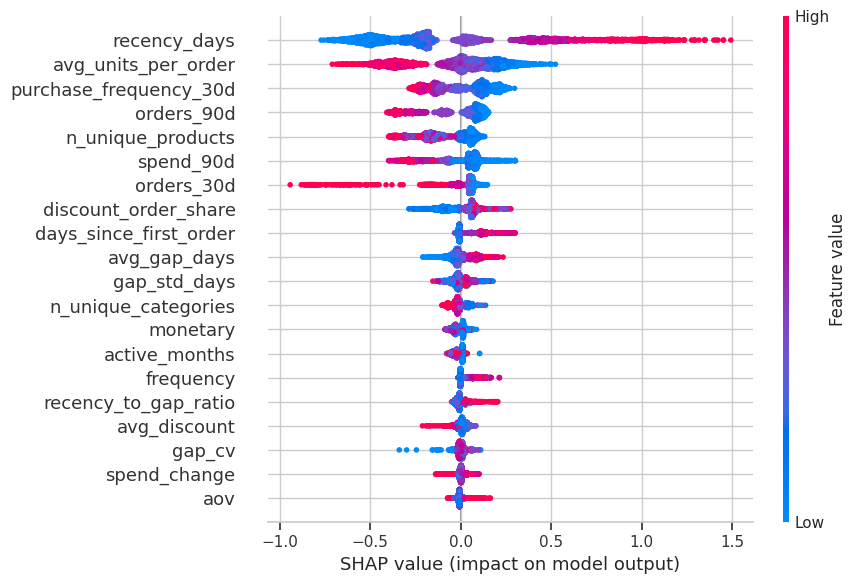

In [4]:
shap.summary_plot(sv, X, show=False, plot_size=(9, 6)); plt.show()

In [5]:
top_shap, top_perm = gi.feature.iloc[0], perm.feature.iloc[0]
display(Markdown(f"""**Reading the importances.** SHAP ranks `{top_shap}` first; permutation importance (drop in test PR-AUC when a feature is shuffled) ranks `{top_perm}` first. Agreement between two independent methods increases confidence; disagreement is a reason to look closer.
Features that share information (frequency, 90-day orders, spend...) split the credit among themselves. Importances describe what the *model* uses on *this* dataset; they are not universal laws and not causes."""))

**Reading the importances.** SHAP ranks `recency_days` first; permutation importance (drop in test PR-AUC when a feature is shuffled) ranks `recency_days` first. Agreement between two independent methods increases confidence; disagreement is a reason to look closer.
Features that share information (frequency, 90-day orders, spend...) split the credit among themselves. Importances describe what the *model* uses on *this* dataset; they are not universal laws and not causes.

## Individual explanations

Highest-risk customer: C01130 | churn probability 69% | actual outcome: retained
  Factors increasing risk:
   + 83 days since last purchase
   + 23 spent in the last 90 days
   + silent 6.2x longer than their usual gap
  Factors reducing risk:
   - 1.87 orders per 30 days of life
   - 8 product categories explored
   - usually 13 days between orders

A low-risk customer: C05362 | churn probability 4% | actual outcome: retained
  Factors increasing risk:
   + 615 days since first order
   + 70 orders placed so far
   + 615 days since registration
  Factors reducing risk:
   - 4.5 units per order
   - 6 orders in the last 90 days
   - 12 days since last purchase



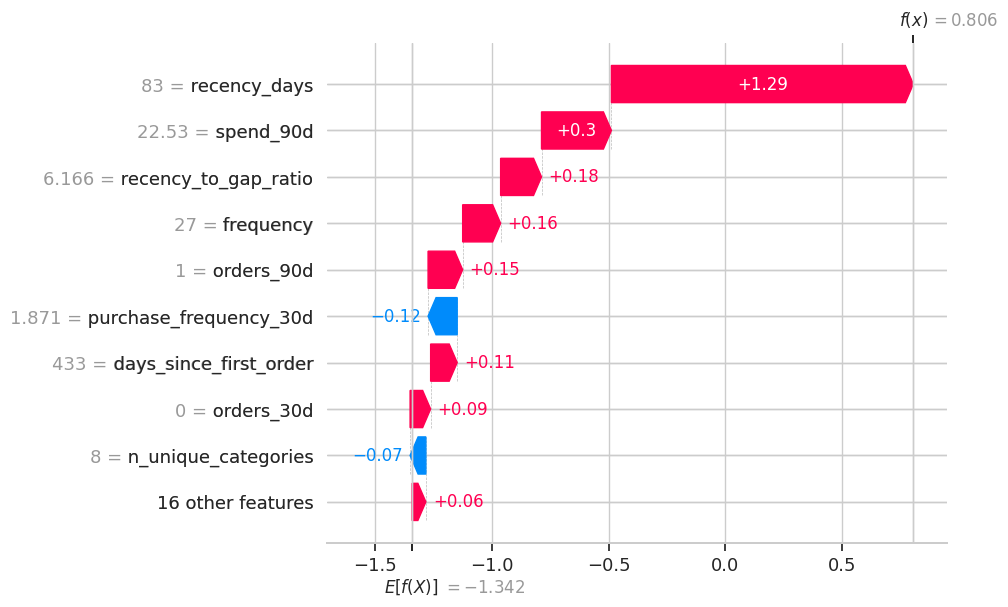

In [6]:
p = model.predict_proba(X)[:, 1]
for label, i in [("Highest-risk customer", int(np.argmax(p))), ("A low-risk customer", int(np.argsort(p)[len(p)//10]))]:
    up, down = xai.explain_row(sv[i], X.iloc[i], 3)
    print(f"{label}: {test.customer_id[i]} | churn probability {p[i]:.0%} | actual outcome: {'churned' if y.iloc[i] else 'retained'}")
    print("  Factors increasing risk:"); [print("   +", s) for s in up]
    print("  Factors reducing risk:");   [print("   -", s) for s in down]; print()
shap.plots.waterfall(shap.Explanation(sv[int(np.argmax(p))], base, X.iloc[int(np.argmax(p))].to_numpy(), feature_names=feats), show=False); plt.show()

## Prioritisation: risk x value
Churn probability alone is not a plan. Two High-risk customers with very different annual value deserve different responses. The playbook below maps (risk tier, value tier) to a *suggested* action. It supports a human decision, it does not make it.

In [7]:
from src.prioritization import PLAYBOOK, WINBACK
cs = pd.read_csv(DATA_PROC / "customers_scored.csv.gz")
pb = pd.DataFrame([(r, v, *a) for (r, v), a in PLAYBOOK.items()], columns=["risk", "value", "priority", "action"]); display(pb)
act = cs[cs.status == "Active"]
display(pd.crosstab(act.risk_level, act.value_tier).reindex(index=["High","Medium","Low"], columns=["High","Medium","Low"]))
summary = act.groupby("priority").agg(customers=("customer_id", "size"), expected_margin_at_risk=("margin_at_risk", "sum"), mean_churn_prob=("churn_prob", "mean")).round(2); display(summary)

,risk,value,priority,action
0,High,High,P1 - Critical,Personal outreach: customer-service call or ac...
1,High,Medium,P2 - High,Personalised email with product recommendation...
2,High,Low,P3 - Low-cost,Automated reminder email / 'we miss you' messa...
3,Medium,High,P2 - High,"Loyalty communication (early access, thank-you..."
4,Medium,Medium,P3 - Low-cost,Automated reminder or product-recommendation e...
5,Medium,Low,P4 - Monitor,Keep in regular newsletter; re-score next month
6,Low,High,P5 - Maintain,Loyalty / VIP communication; do NOT discount (...
7,Low,Medium,P5 - Maintain,Business-as-usual communication
8,Low,Low,P5 - Maintain,Business-as-usual communication


value_tier,High,Medium,Low
risk_level,,,
High,58,174,93
Medium,145,401,97
Low,1482,406,15


,customers,expected_margin_at_risk,mean_churn_prob
priority,,,
P1 - Critical,58,20080.30,0.52
P2 - High,319,51485.82,0.43
P3 - Low-cost,494,33385.84,0.39
P4 - Monitor,97,2651.97,0.37
P5 - Maintain,1903,150393.93,0.13


## CLV proxy - assumptions stated plainly
`clv_12m_proxy = annual margin run-rate x average survival over the next 12 months`, where run-rate = historical spend / observed life (at least 90 days) x 365, margin = a flat assumed share of revenue (`business.gross_margin` in the config, shown in the banner of the dashboard), and the model's churn probability for one H-day window is assumed constant in each future window. This is a **heuristic**. A rigorous CLV would use a probabilistic purchase model (e.g. BG/NBD + Gamma-Gamma) validated on a hold-out period.

In [8]:
top = act.sort_values("priority_score", ascending=False).head(10)[["customer_id","rfm_segment","churn_prob","risk_level","annual_margin_run_rate","clv_12m_proxy","margin_at_risk","priority"]]
display(top.round(2))
p1 = act[act.priority.str.startswith("P1")]
display(Markdown(f"""**So what?** Of {len(act):,} active customers, **{len(p1)}** are both High-risk and High-value (P1) with ~{p1.margin_at_risk.sum():,.0f} of expected annual margin at stake: compare this with the size of the other groups to judge whether personal outreach is feasible. Lower-value groups get automated, low-cost messages. {int((act.risk_level=='Low').sum()):,} Low-risk customers are deliberately **left alone**: contacting them wastes budget and discounting them gives away margin."""))

,customer_id,rfm_segment,churn_prob,risk_level,annual_margin_run_rate,clv_12m_proxy,margin_at_risk,priority
1695,C01696,Loyal customers,0.68,High,2849.06,271.48,1927.47,P1 - Critical
2574,C02575,Loyal customers,0.43,Medium,3564.01,891.96,1528.04,P2 - High
1014,C01015,Loyal customers,0.54,High,1680.17,280.95,906.35,P1 - Critical
5383,C05385,Loyal customers,0.59,High,1523.68,206.26,904.57,P1 - Critical
4842,C04844,Loyal customers,0.40,Medium,2209.80,611.00,884.33,P2 - High
2099,C02100,Potential loyalists,0.43,Medium,1920.32,480.89,822.99,P2 - High
2767,C02768,Loyal customers,0.31,Medium,2192.03,820.31,681.84,P2 - High
4889,C04891,Potential loyalists,0.33,Medium,1936.52,674.56,643.84,P2 - High
1077,C01078,Champions,0.17,Low,3550.24,2111.57,598.01,P5 - Maintain
5218,C05220,Loyal customers,0.59,High,970.94,133.59,572.48,P1 - Critical


**So what?** Of 2,871 active customers, **58** are both High-risk and High-value (P1) with ~20,080 of expected annual margin at stake: compare this with the size of the other groups to judge whether personal outreach is feasible. Lower-value groups get automated, low-cost messages. 1,903 Low-risk customers are deliberately **left alone**: contacting them wastes budget and discounting them gives away margin.